# spatial-smooth: a tutorial

A per-cell signature score is noisy — each cell is measured independently, so dropout and
sampling variance dominate. **Smoothing** lets neighbouring cells borrow statistical strength.
The scientific choice is *which* neighbours count:

| smoothing | neighbours are… | recovers |
|---|---|---|
| **spatial** | physically adjacent cells | tissue architecture: niches, layers, gradients |
| **cell state** | transcriptionally similar cells | biology, independent of position |
| **both, composed** | first the manifold, then the tissue | denoised expression laid out in space |

This notebook walks three levels of control:

1. **One line.** Defaults do everything.
2. **Parameterized.** Choose the pipeline; forward plotting kwargs to scanpy/squidpy.
3. **Fully modular.** Compute → store → write to disk → reload → **plot without recomputing.**

The data is a public 10x Genomics Xenium mouse-brain section (CC-BY), downloaded on first run
(~4.5 MB). Nothing here needs a cluster.

## Setup

Only `numpy`, `scipy`, `pandas` and `anndata` are hard requirements. The Gaussian-process step
needs `kompot`, the diffusion map `palantir`, plotting `scanpy` (and optionally `squidpy`). Each
is imported lazily and, when missing, reported with the exact `pip install` line.

```bash
pip install "spatial-smooth[all]"
# kompot >= 0.8.0 (for `smooth_expression`) is not on PyPI yet:
pip install "kompot @ git+https://github.com/settylab/kompot.git"
```

In [1]:
%matplotlib inline
import os

# Cap thread pools before the scientific stack imports (polite on shared machines).
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import numpy as np
import pandas as pd
import scanpy as sc

import spatial_smooth as ss

sc.settings.verbosity = 1
ss.check_dependencies()

spatial_smooth v0.1.0 -- dependency check
  numpy       2.4.6       ok
  pandas      2.3.3       ok
  scipy       1.18.0      ok
  anndata     0.12.17     ok
  kompot      0.8.0       ok (optional)
  palantir    1.4.4       ok (optional)
  scanpy      1.12.1      ok (optional)
  squidpy     1.8.2       ok (optional)
  KDEpy       1.1.12      ok (optional)
  matplotlib  3.11.0      ok (optional)

  All dependencies present.


{'numpy': '2.4.6',
 'pandas': '2.3.3',
 'scipy': '1.18.0',
 'anndata': '0.12.17',
 'kompot': '0.8.0',
 'palantir': '1.4.4',
 'scanpy': '1.12.1',
 'squidpy': '1.8.2',
 'KDEpy': '1.1.12',
 'matplotlib': '3.11.0'}

## 1. The data

### Using your own data instead

**`spatial-smooth` needs exactly two things** from an `AnnData`, and nothing else:

1. `adata.X` (or a layer you name via `layer=`) holding **log-normalised** expression, and
2. `adata.obsm["spatial"]` holding the cells' physical coordinates, as an `(n_obs, 2)` array.

So if you already have a prepared object, skip the download entirely — this is the whole of
section 1 for you:

```python
import anndata as ad
adata = ad.read_h5ad("my_section.h5ad")
assert "spatial" in adata.obsm          # (n_obs, 2) coordinates
# adata.X must be log-normalised; if it holds raw counts:
#   adata.layers["counts"] = adata.X.copy()
#   sc.pp.normalize_total(adata); sc.pp.log1p(adata)
```

Then jump to section 2. Cell-state smoothing (`steps="dm"`) additionally wants
`obsm["DM_EigenVectors"]`, which `ss.smooth(..., auto_embed=True)` computes for you if absent.

### The example dataset

The rest of this notebook uses a public 10x Xenium mouse-brain coronal subset: ~36,000 cells, a
248-gene panel, one cell per row with physical centroids. We fetch the two small loose outputs
(cached, so re-running is free), assemble an `AnnData`, and put the centroids in
`obsm["spatial"]`.

In [2]:
import pathlib, urllib.request

BASE = ("https://cf.10xgenomics.com/samples/xenium/1.0.2/"
        "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP")
NAME = "Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP"
DATA = pathlib.Path("data/xenium_mousebrain")
DATA.mkdir(parents=True, exist_ok=True)

# Point this at your own .h5ad to run the whole notebook on your data instead.
PREPARED = pathlib.Path("data/prepared.h5ad")

for fname in (f"{NAME}_cell_feature_matrix.h5", f"{NAME}_cells.csv.gz"):
    dest = DATA / fname
    if PREPARED.exists():
        break
    if not dest.exists():
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(f"{BASE}/{fname}", dest)
    print(f"  {fname}  ({dest.stat().st_size / 1e6:.1f} MB)")

  Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_cell_feature_matrix.h5  (2.9 MB)
  Xenium_V1_FF_Mouse_Brain_Coronal_Subset_CTX_HP_cells.csv.gz  (1.7 MB)


In [3]:
import anndata as ad

if PREPARED.exists():
    # --- alternative path: load an object you prepared earlier -------------------
    adata = ad.read_h5ad(PREPARED)
    print(f"loaded {PREPARED}")
else:
    # --- example path: assemble the public Xenium section ------------------------
    adata = sc.read_10x_h5(DATA / f"{NAME}_cell_feature_matrix.h5")
    adata.var_names_make_unique()

    cells = pd.read_csv(DATA / f"{NAME}_cells.csv.gz").set_index("cell_id")
    cells.index = cells.index.astype(str)
    adata.obs_names = adata.obs_names.astype(str)
    adata.obs = adata.obs.join(cells, how="left")
    adata.obsm["spatial"] = adata.obs[["x_centroid", "y_centroid"]].to_numpy()

    sc.pp.filter_cells(adata, min_counts=10)
    adata.layers["counts"] = adata.X.copy()
    sc.pp.normalize_total(adata)
    sc.pp.log1p(adata)

# The only two preconditions, checked explicitly.
assert "spatial" in adata.obsm, "spatial-smooth needs obsm['spatial']"
assert adata.X.max() < 100, "adata.X should be log-normalised, not raw counts"

print(f"{adata.n_obs:,} cells x {adata.n_vars} genes")

36,419 cells x 248 genes


A small **hippocampal** program from the panel — dentate-gyrus and CA markers. Four genes, each
sparse and noisy on its own.

In [4]:
HIPPOCAMPUS = ["Prox1", "Neurod6", "Wfs1", "Fibcd1"]
assert set(HIPPOCAMPUS) <= set(adata.var_names)
HIPPOCAMPUS

['Prox1', 'Neurod6', 'Wfs1', 'Fibcd1']

## 2. Level one — one line, defaults do everything

`ss.smooth` with no `steps` argument smooths over `obsm["spatial"]` with a Gaussian kernel across
each cell's 100 nearest spatial neighbours. The bandwidth is inferred from the data (six median
nearest-neighbour distances), so you do not pick a number in microns.

`ss.pl.signature` then plots the raw score next to the smoothed one.

CPU times: user 610 ms, sys: 460 ms, total: 1.07 s
Wall time: 688 ms


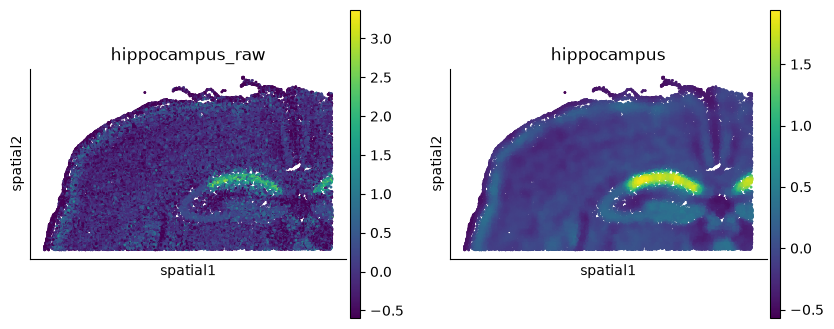

In [5]:
%time ss.smooth(adata, HIPPOCAMPUS, "hippocampus")

ss.pl.signature(adata, "hippocampus")

The raw panel is a speckle of individual cells; the smoothed panel resolves the dentate-gyrus
C-shape, the CA fields, and the cortical layers. Two columns appeared in `obs`, and a record of
what was run in `uns`.

In [6]:
print(adata.obs[["hippocampus_raw", "hippocampus"]].describe().T)
print()

prov = ss.provenance(adata, "hippocampus")
print("genes    :", prov["genes"])
print("score    :", prov["score"])
print("pipeline :", [s["kind"] for s in prov["steps"]])
print("bandwidth:", round(prov["steps"][0]["resolved"]["sigma_used"], 1), "um  (inferred)")

                   count          mean       std       min       25%  \
hippocampus_raw  36419.0 -3.351830e-09  0.488344 -0.592023 -0.302019   
hippocampus      36419.0  6.364337e-03  0.338783 -0.565146 -0.156904   

                      50%       75%       max  
hippocampus_raw -0.051674  0.205903  3.372188  
hippocampus     -0.058279  0.049505  1.945165  

genes    : ['Prox1', 'Neurod6', 'Wfs1', 'Fibcd1']
score    : mean_z
pipeline : ['knn_gaussian']
bandwidth: 78.2 um  (inferred)


## 3. Level two — choose the pipeline, control the plot

### 3a. Composition: spatial, cell state, or both

`steps` selects what you smooth over:

| `steps` | pipeline | meaning |
|---|---|---|
| `"spatial"` (default) | `[KnnGaussian()]` | spatial only |
| `"dm"` | `[KompotGP()]` | cell state only |
| `"dm+spatial"` | `[KompotGP(), KnnGaussian()]` | both, cell state first |

Doing *just one of the two* is the ordinary case, not a special one — a one-element pipeline.
Composing runs the steps left to right: the spatial step smooths the expression the
cell-state step already denoised.

The cell-state step is a Gaussian-process regression over a diffusion map of the expression
manifold (`kompot.smooth_expression`, built on `mellon`). It needs `obsm["DM_EigenVectors"]`;
with `auto_embed=True` (the default) `spatial-smooth` computes it with Palantir if absent.

The GP is the expensive path, so we subsample for this section — the point is the API, not the
wall clock.

In [7]:
rng = np.random.default_rng(0)
keep = rng.choice(adata.n_obs, size=12_000, replace=False)
sub = adata[np.sort(keep)].copy()

%time ss.compute_diffusion_map(sub)           # Palantir -> obsm["DM_EigenVectors"]
sub.obsm["DM_EigenVectors"].shape

CPU times: user 26 s, sys: 666 ms, total: 26.7 s
Wall time: 26.6 s


(12000, 10)

In [8]:
# cell state only: GP over the diffusion map
%time ss.smooth(sub, HIPPOCAMPUS, "dm_only", steps="dm")

# spatial only: Gaussian kNN over tissue coordinates
%time ss.smooth(sub, HIPPOCAMPUS, "spatial_only", steps="spatial")

# both, composed: manifold first, then tissue
%time ss.smooth(sub, HIPPOCAMPUS, "composed", steps="dm+spatial")

ss.list_results(sub)

[2026-07-09 14:28:25,426] [INFO    ] Smoothing all 12,000 cells


CPU times: user 1min 53s, sys: 35.9 s, total: 2min 29s
Wall time: 1min 4s
CPU times: user 192 ms, sys: 18.6 ms, total: 211 ms
Wall time: 114 ms
[2026-07-09 14:29:28,398] [INFO    ] Smoothing all 12,000 cells


CPU times: user 1min 46s, sys: 34.3 s, total: 2min 20s
Wall time: 56.6 s


['composed', 'dm_only', 'hippocampus', 'spatial_only']

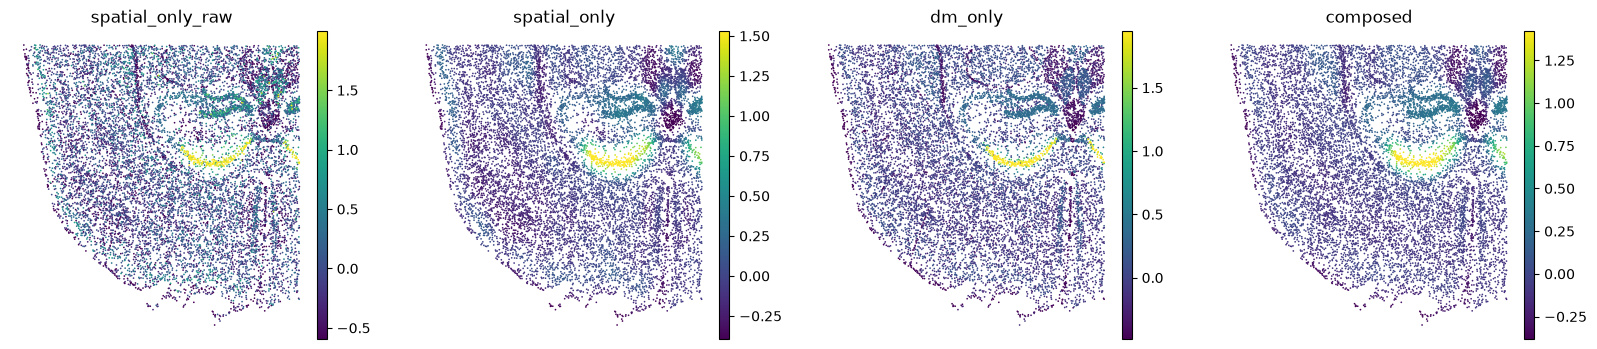

In [9]:
ss.pl.compare(
    sub, ["spatial_only", "dm_only", "composed"], raw=True,
    backend="scanpy", ncols=4, size=6, frameon=False,
)

Read the four panels left to right: the raw score, then each pipeline. Spatial smoothing produces
the cleanest tissue field. Cell-state smoothing denoises without ever consulting position — its
field is spatially coherent only because cells of the same type sit together. Composing does both,
and is the smoothest of the three.

### 3b. Plot control: kwargs go straight through

`ss.pl.signature` is a wrapper, not a reimplementation. Everything after `name` is forwarded
**verbatim** to the backend:

| `backend` | underlying call |
|---|---|
| `"squidpy"` | `squidpy.pl.spatial_scatter` |
| `"scanpy"` | `scanpy.pl.embedding` |
| `"scanpy-spatial"` | `scanpy.pl.spatial` |
| `"auto"` (default) | squidpy if installed, else scanpy |

`color` is set for you from the stored provenance. Defaults (`cmap`, percentile colour limits,
a grey `na_color`) are injected only for keys you did not pass.

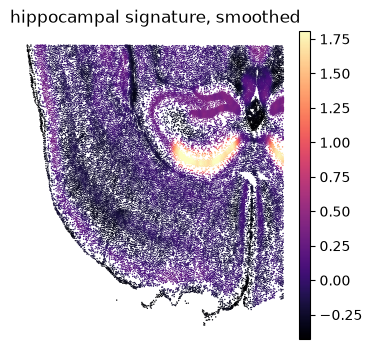

In [10]:
ss.pl.signature(
    adata, "hippocampus", raw=False,
    backend="scanpy",          # -> scanpy.pl.embedding
    cmap="magma", size=4, vmax="p99.5", frameon=False,
    title="hippocampal signature, smoothed",
)

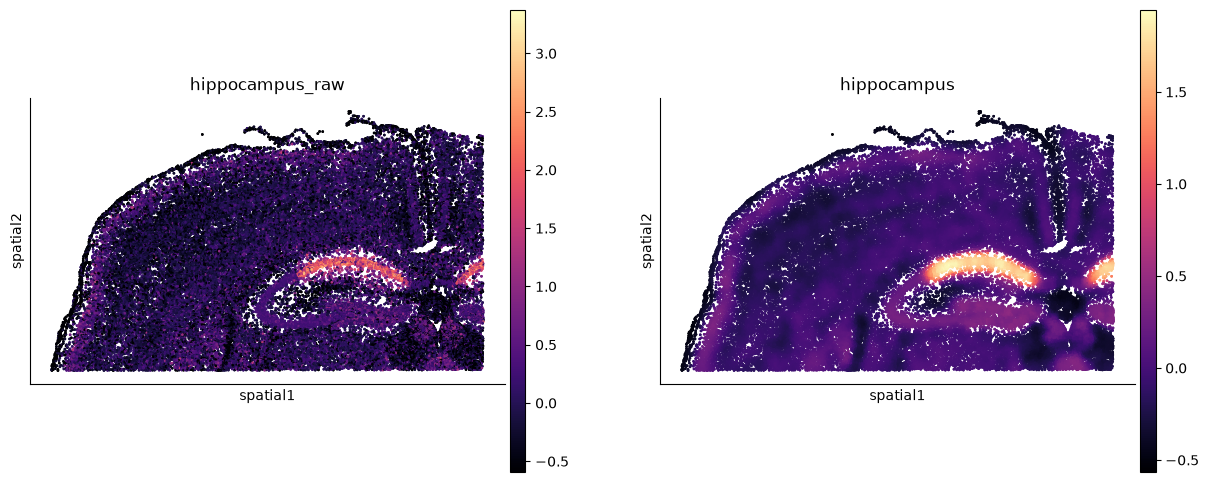

In [11]:
# The same result through squidpy, which knows about tissue images and library ids.
ss.pl.signature(adata, "hippocampus", backend="squidpy", cmap="magma", figsize=(6, 6))

### 3c. Bandwidth is scale-invariant

Every default bandwidth is a multiple of the median nearest-neighbour distance, so the same
factor smooths the same amount whether coordinates are microns or millimetres. Rescale the
coordinates a thousandfold and the field is unchanged.

In [12]:
rescaled = adata.copy()
rescaled.obsm["spatial"] = rescaled.obsm["spatial"] * 1000.0
ss.smooth(rescaled, HIPPOCAMPUS, "hippocampus")

a = adata.obs["hippocampus"].to_numpy()
b = rescaled.obs["hippocampus"].to_numpy()
print("max |difference| :", np.abs(a - b).max())
print("sigma (um)  :", round(ss.provenance(adata, "hippocampus")["steps"][0]["resolved"]["sigma_used"], 2))
print("sigma (nm)  :", round(ss.provenance(rescaled, "hippocampus")["steps"][0]["resolved"]["sigma_used"], 2))

max |difference| : 0.0
sigma (um)  : 78.15
sigma (nm)  : 78152.78


> **One caveat worth internalising.** The Gaussian process infers its length scale the same way,
> via `ls_factor`. Over a diffusion map kompot's native `ls_factor=10` is right; over *physical*
> coordinates it is ~200x the cell spacing and washes the field into a single global gradient.
> Use `ls_factor≈0.3` there — which is exactly what the `"spatial-gp"` shorthand does.

## 4. Level three — fully modular: compute, store, plot later

Pass `Step` objects instead of a shorthand for complete control. Each step is a frozen dataclass:
a *specification*, not a fitted object, so it can be reused and is recorded verbatim.

In [13]:
pipeline = [
    ss.KompotGP(basis="DM_EigenVectors", ls_factor=10.0, n_landmarks=2000),
    ss.KnnGaussian(basis="spatial", k=64, sigma_factor=4.0),
]
pipeline

[KompotGP(basis='DM_EigenVectors', sigma=1.0, ls=None, ls_factor=10.0, n_landmarks=2000, groupby=None, condition=None, random_state=0),
 KnnGaussian(basis='spatial', k=64, sigma=None, sigma_factor=4.0, workers=-1)]

In [14]:
%time ss.smooth(sub, HIPPOCAMPUS, "custom", steps=pipeline, store_genes=True)

print("smoothed score      :", sub.obs["custom"].shape)
print("smoothed expression :", sub.obsm["custom_smoothed"].shape)   # store_genes=True

[2026-07-09 14:30:29,396] [INFO    ] Smoothing all 12,000 cells


CPU times: user 29 s, sys: 5.92 s, total: 35 s
Wall time: 14.2 s
smoothed score      : (12000,)
smoothed expression : (12000, 4)


### The persistence contract

Everything is in the `AnnData`:

| key | contents |
|---|---|
| `adata.obs[name]` | smoothed score |
| `adata.obs[f"{name}_raw"]` | unsmoothed score, same genes and combiner |
| `adata.obsm[f"{name}_smoothed"]` | `(n_obs, n_genes)` smoothed expression (`store_genes=True`) |
| `adata.uns["spatial_smooth"][name]` | provenance: genes, pipeline, resolved bandwidths, version |

Write it out, and a later plotting call reads those keys. **Nothing is recomputed** — no `kompot`,
no `palantir`, no GP solve. That is what makes an expensive smoothing worth doing once.

In [15]:
import anndata as ad

sub.write_h5ad("smoothed.h5ad")

reloaded = ad.read_h5ad("smoothed.h5ad")
print("stored results:", ss.list_results(reloaded))

prov = ss.provenance(reloaded, "custom")
for step in prov["steps"]:
    print(f"  {step['kind']:<14} basis={step['basis']:<18} resolved={step['resolved']}")

stored results: ['composed', 'custom', 'dm_only', 'hippocampus', 'spatial_only']
  kompot_gp      basis=DM_EigenVectors    resolved={'kompot_version': '0.8.0', 'n_landmarks_used': 2000}
  knn_gaussian   basis=spatial            resolved={'k_used': 64, 'sigma_used': 67.45146702575732}


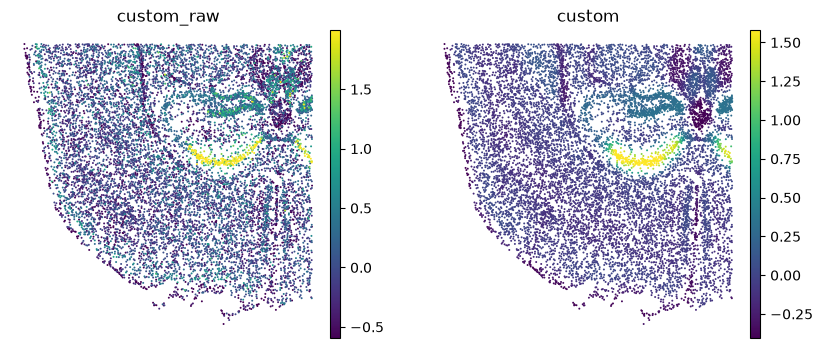

CPU times: user 233 ms, sys: 53.6 ms, total: 286 ms
Wall time: 286 ms


In [16]:
# No recomputation: this is a table lookup and a scatter plot.
%time ss.pl.signature(reloaded, "custom", backend="scanpy", size=8, frameon=False)

Compare that timing with the `%time` on the `ss.smooth` call above. The plot is instantaneous
because the field was never recomputed — `spatial_smooth.plot` reads `obs` and `uns` and calls
scanpy. The package's test suite asserts this adversarially: it blocks `kompot`, `KDEpy` and
`palantir` at the import machinery, replaces every compute entry point with a function that
raises, and *then* renders a reloaded `.h5ad`.

## 5. Odds and ends

### Restrict to a subset of cells

Cells filtered out neither train the smoother nor receive the field. The call returns a **new,
smaller** `AnnData` — use the return value.

In [17]:
# A coarse annotation to filter on (this public subset ships none).
adata.obs["half"] = np.where(
    adata.obsm["spatial"][:, 0] < np.median(adata.obsm["spatial"][:, 0]), "left", "right"
)

left = ss.smooth(adata, HIPPOCAMPUS, "hippocampus", subset_key="half", include=["left"])
print(f"{adata.n_obs:,} cells -> {left.n_obs:,} after the filter")
print("provenance n_obs:", ss.provenance(left, "hippocampus")["n_obs"])

36,419 cells -> 18,209 after the filter
provenance n_obs: 18209


### Fit the GP on one condition, evaluate everywhere

`KompotGP(groupby=..., condition=...)` trains on one group and imputes the field for all cells —
useful when one arm of an experiment is the reference.

### Other engines

`Kde` (a fine-grid FFT Nadaraya-Watson estimator, via `KDEpy`) renders a field rather than a
neighbour average; `"spatial-gp"` puts the Gaussian process on tissue coordinates with a sensible
`ls_factor`. Both are one `steps` argument away.

```python
ss.smooth(adata, HIPPOCAMPUS, "kde",        steps="spatial-kde")
ss.smooth(adata, HIPPOCAMPUS, "spatial_gp", steps="spatial-gp")
```

### Where to go next

* `ss.provenance(adata, name)` — exactly what was run, with resolved bandwidths.
* `ss.check_dependencies()` — what is installed, and the pip line for what is not.
* The **Concepts** page of the documentation — composition semantics, the scoring contract, and
  why gene-level smoothing costs nothing in correctness.